# VCT Matchup Analysis Toolkit

Reusable classical-statistics functions for analyzing **any two-team VCT matchup**: veto tendencies, map win rates + round differentials, win probability (log5), and a full veto-order simulation.

**Requirements:** `pip install pandas numpy matplotlib openpyxl`

**Usage:** run all cells to define the functions, then at the bottom call:
```python
df = load_data("VCT2026-Merged.xlsx")
results = analyze_matchup(df, "Team A", "Team B")
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Column groups (match the merged dataset schema)
PICK_COLS = ["Team1Pick1", "Team2Pick1", "Team1Pick2", "Team2Pick2"]
BAN_COLS = ["Team1Ban1", "Team2Ban1", "Team1Ban2", "Team2Ban2"]
MAP_COLS = [f"Map {i}" for i in range(1, 6)]
MAP_WINNER_COLS = [f"Map {i} Winner" for i in range(1, 6)]

## 1. Data loading & Team Selection

In [3]:
def load_data(path: str) -> pd.DataFrame:
    """Load the merged VCT dataset (.xlsx or .xls)."""
    return pd.read_excel(path)


def resolve_team_name(name: str, df: pd.DataFrame) -> str:
    """Case-insensitive lookup of a team's exact name as stored in the data."""
    all_teams = set(df["Team 1"]) | set(df["Team 2"])
    match = [t for t in all_teams if t.strip().upper() == name.strip().upper()]
    if not match:
        raise ValueError(
            f"Team '{name}' not found. Available teams:\n" + "\n".join(sorted(all_teams))
        )
    return match[0]


def get_full_map_pool(df: pd.DataFrame) -> set:
    """All maps that have ever appeared in the dataset (played, picked, banned, or decider)."""
    maps = set()
    for col in MAP_COLS + PICK_COLS + BAN_COLS + ["Decider"]:
        maps |= set(df[col].dropna().unique())
    return maps

In [4]:
MERGED_FILE = "VCT2026.xlsx"  # update this path
df = pd.read_excel(MERGED_FILE)

all_teams = sorted(set(df["Team 1"]) | set(df["Team 2"]))
print(f"{len(all_teams)} teams found:\n")
for t in all_teams:
    print(f"  {t}")

map_pool = get_full_map_pool(df)
print(len(map_pool), sorted(map_pool))

50 teams found:

  100 THIEVES
  ALL GAMERS
  BBL ESPORTS
  BILIBILI GAMING
  CLOUD9
  DETONATION FOCUSME
  DRAGON RANGER GAMING
  EDWARD GAMING
  ENVY
  ETERNAL FIRE
  EVIL GENIUSES
  FNATIC
  FULL SENSE
  FUN PLUS PHOENIX
  FURIA
  FUT ESPORTS
  G2 ESPORTS
  GEN.G
  GENTLE MATES
  GIANTX
  GLOBAL ESPORTS
  JDG ESPORTS
  KARMINE CORP
  KIWOOM DRX
  KRU ESPORTS
  LEVIATAN
  LOUD
  MIBR
  NATUS VINCERE
  NONGSHIM REDFORCE
  NOVA ESPORTS
  NRG
  PACIFIC ESPORTS
  PAPER REX
  PCIFIC ESPORTS
  REX REGUM QEON
  SENTINELS
  T1
  TEAM HERETICS
  TEAM LIQUID
  TEAM SECRET
  TEAM VITALITY
  TITAN ESPORTS CLUB
  TRACE ESPORTS
  TYLOO
  ULF ESPORTS
  VARREL
  WOLVES ESPORTS
  XI LAI GAMING
  ZETA DIVISION
10 ['Abyss', 'Ascent', 'Bind', 'Breeze', 'Corrode', 'Fracture', 'Haven', 'Lotus', 'Pearl', 'Split']


In [5]:

Team1 = "BBL ESPORTS"
Team2 = "PCIFIC ESPORTS"
MATCH_FORMAT = "bo3"   # change to "bo5" for a best-of-5

## 2. Veto tendencies (pick rate / ban rate per map, per team)

In [6]:
def veto_tendencies(df: pd.DataFrame, team: str) -> pd.DataFrame:
    """Returns a DataFrame indexed by map with pick_rate/pick_count and
    ban_rate/ban_count (rates normalized to sum to 1 across that team's
    picked/banned maps)."""
    picks, bans = [], []

    for _, row in df.iterrows():
        if row["Team 1"] == team:
            picks += [row["Team1Pick1"], row["Team1Pick2"]]
            bans += [row["Team1Ban1"], row["Team1Ban2"]]
        elif row["Team 2"] == team:
            picks += [row["Team2Pick1"], row["Team2Pick2"]]
            bans += [row["Team2Ban1"], row["Team2Ban2"]]

    picks = pd.Series([m for m in picks if pd.notna(m)])
    bans = pd.Series([m for m in bans if pd.notna(m)])

    pick_rate = picks.value_counts(normalize=True).rename("pick_rate")
    ban_rate = bans.value_counts(normalize=True).rename("ban_rate")
    pick_count = picks.value_counts().rename("pick_count")
    ban_count = bans.value_counts().rename("ban_count")

    out = pd.concat([pick_rate, pick_count, ban_rate, ban_count], axis=1).fillna(0)
    return out.sort_values("pick_rate", ascending=False)

## 3. Map win rate & round differential

In [7]:
def map_win_rates(df: pd.DataFrame, team: str) -> pd.DataFrame:
    """Per-map win_rate, avg_round_diff, and maps_played for a team."""
    records = []
    for _, row in df.iterrows():
        if row["Team 1"] == team:
            is_team1 = True
        elif row["Team 2"] == team:
            is_team1 = False
        else:
            continue

        for i in range(1, 6):
            played_map = row[f"Map {i}"]
            winner = row[f"Map {i} Winner"]
            t1_rounds = row[f"M{i}T1"]
            t2_rounds = row[f"M{i}T2"]
            if pd.isna(played_map) or pd.isna(winner) or pd.isna(t1_rounds) or pd.isna(t2_rounds):
                continue

            team_rounds = t1_rounds if is_team1 else t2_rounds
            opp_rounds = t2_rounds if is_team1 else t1_rounds

            records.append({
                "map": played_map,
                "won": winner == team,
                "round_diff": team_rounds - opp_rounds,
            })

    if not records:
        return pd.DataFrame(columns=["win_rate", "avg_round_diff", "maps_played"])

    rdf = pd.DataFrame(records)
    summary = rdf.groupby("map").agg(
        win_rate=("won", "mean"),
        avg_round_diff=("round_diff", "mean"),
        maps_played=("won", "count"),
    )
    return summary.sort_values("win_rate", ascending=False)

## 4. Overall win rate & head-to-head

In [8]:
def overall_win_rate(df: pd.DataFrame, team: str):
    """Returns (win_rate, matches_played)."""
    matches = df[(df["Team 1"] == team) | (df["Team 2"] == team)]
    matches = matches.dropna(subset=["MatchWinner"])
    if matches.empty:
        return np.nan, 0
    wins = (matches["MatchWinner"] == team).sum()
    return wins / len(matches), len(matches)


def head_to_head(df: pd.DataFrame, team_a: str, team_b: str):
    """Returns (team_a_wins, team_b_wins, total_meetings)."""
    mask = ((df["Team 1"] == team_a) & (df["Team 2"] == team_b)) | (
        (df["Team 1"] == team_b) & (df["Team 2"] == team_a)
    )
    h2h = df[mask].dropna(subset=["MatchWinner"])
    a_wins = (h2h["MatchWinner"] == team_a).sum()
    b_wins = (h2h["MatchWinner"] == team_b).sum()
    return a_wins, b_wins, len(h2h)

## 5. Win probability — log5 formula (classical sabermetrics)

$$P(A \text{ beats } B) = \frac{W_A - W_A W_B}{W_A + W_B - 2 W_A W_B}$$

Blended with the actual head-to-head record, weighted up as more meetings accumulate (capped at 50% weight).

In [9]:
def log5(win_rate_a: float, win_rate_b: float) -> float:
    """Bill James' log5 formula: P(A beats B) given standalone win rates."""
    if np.isnan(win_rate_a) or np.isnan(win_rate_b):
        return np.nan
    wa = np.clip(win_rate_a, 0.01, 0.99)
    wb = np.clip(win_rate_b, 0.01, 0.99)
    return (wa - wa * wb) / (wa + wb - 2 * wa * wb)


def win_probability(df: pd.DataFrame, team_a: str, team_b: str) -> dict:
    """Blends log5(overall win rate) with actual head-to-head record,
    weighting head-to-head more heavily as more meetings accumulate
    (capped at 50% weight)."""
    wr_a, n_a = overall_win_rate(df, team_a)
    wr_b, n_b = overall_win_rate(df, team_b)
    p_overall = log5(wr_a, wr_b)

    h2h_a, h2h_b, h2h_n = head_to_head(df, team_a, team_b)

    if h2h_n > 0:
        p_h2h = h2h_a / h2h_n
        h2h_weight = min(0.5, h2h_n / (h2h_n + 5))
        p_final = (1 - h2h_weight) * p_overall + h2h_weight * p_h2h
    else:
        p_final = p_overall

    return {
        "team_a_win_rate": wr_a, "team_a_matches": n_a,
        "team_b_win_rate": wr_b, "team_b_matches": n_b,
        "h2h_a_wins": h2h_a, "h2h_b_wins": h2h_b, "h2h_meetings": h2h_n,
        "win_prob_a": p_final, "win_prob_b": 1 - p_final,
    }

## 6. Full veto simulation

Format-aware veto order:
- **Bo3**: `Ban, Ban, Pick, Pick, Ban, Ban, Decider` (2 bans + 1 pick per team)
- **Bo5**: `Ban, Ban, Pick, Pick, Pick, Pick, Decider` (1 ban + 2 picks per team)

In [10]:
def simulate_veto(veto_a: pd.DataFrame, veto_b: pd.DataFrame,
                   team_a: str, team_b: str, map_pool: set,
                   match_format: str = "bo3") -> list:
    """Simulates the veto for either format:
      - 'bo3': 2 bans + 1 pick per team  -> ban,ban,pick,pick,ban,ban,decider
      - 'bo5': 1 ban  + 2 picks per team -> ban,ban,pick,pick,pick,pick,decider
    """
    match_format = match_format.lower()
    if match_format == "bo3":
        action_sequence = ["ban", "ban", "pick", "pick", "ban", "ban"]
    elif match_format == "bo5":
        action_sequence = ["ban", "ban", "pick", "pick", "pick", "pick"]
    else:
        raise ValueError(f"match_format must be 'bo3' or 'bo5', got '{match_format}'")

    remaining = set(map_pool)
    sequence = []
    turn_order = [(team_a, veto_a), (team_b, veto_b)]

    for i, action in enumerate(action_sequence):
        if len(remaining) <= 1:
            break

        team, veto_df = turn_order[i % 2]
        col = "ban_rate" if action == "ban" else "pick_rate"
        candidates = veto_df.loc[veto_df.index.intersection(remaining)]
        candidates = candidates[candidates[col] > 0].sort_values(col, ascending=False)

        chosen = candidates.index[0] if not candidates.empty else sorted(remaining)[0]

        remaining.discard(chosen)
        sequence.append({"step": f"{team} {action}s", "team": team, "action": action, "map": chosen})

    if len(remaining) == 1:
        sequence.append({"step": "DECIDER", "team": None, "action": "decider", "map": remaining.pop()})
    elif len(remaining) > 1:
        sequence.append({
            "step": "⚠ UNRESOLVED",
            "team": None, "action": "decider",
            "map": f"{len(remaining)} maps left over: {sorted(remaining)} "
                   f"(pool has {len(map_pool)} maps -- {match_format.upper()} expects 7)"
        })

    return sequence

## 7. Visualization

In [11]:
def plot_matchup(veto_a, veto_b, mwr_a, mwr_b, team_a, team_b, figsize=(14, 10)):
    """2x2 grid: pick rate (top) and avg round differential (bottom) per map,
    for each team."""
    fig, axes = plt.subplots(2, 2, figsize=figsize)

    veto_a_sorted = veto_a.sort_values("pick_rate", ascending=True)
    axes[0, 0].barh(veto_a_sorted.index, veto_a_sorted["pick_rate"], color="#4C72B0")
    axes[0, 0].set_title(f"{team_a}: Map Pick Rate")
    axes[0, 0].set_xlabel("Pick rate")
    axes[0, 0].set_xlim(0, 1)

    veto_b_sorted = veto_b.sort_values("pick_rate", ascending=True)
    axes[0, 1].barh(veto_b_sorted.index, veto_b_sorted["pick_rate"], color="#DD8452")
    axes[0, 1].set_title(f"{team_b}: Map Pick Rate")
    axes[0, 1].set_xlabel("Pick rate")
    axes[0, 1].set_xlim(0, 1)

    rd_a_sorted = mwr_a.sort_values("avg_round_diff", ascending=True)
    colors_a = ["#4C72B0" if v >= 0 else "#C44E52" for v in rd_a_sorted["avg_round_diff"]]
    bars = axes[1, 0].barh(rd_a_sorted.index, rd_a_sorted["avg_round_diff"], color=colors_a)
    axes[1, 0].set_title(f"{team_a}: Avg Round Differential by Map")
    axes[1, 0].set_xlabel("Avg round diff (+ = won by, - = lost by)")
    axes[1, 0].axvline(0, color="gray", linestyle="--", linewidth=1)
    for bar, n in zip(bars, rd_a_sorted["maps_played"]):
        x = bar.get_width()
        axes[1, 0].text(x + (0.15 if x >= 0 else -0.15), bar.get_y() + bar.get_height() / 2,
                         f"n={int(n)}", va="center", ha="left" if x >= 0 else "right", fontsize=8)

    rd_b_sorted = mwr_b.sort_values("avg_round_diff", ascending=True)
    colors_b = ["#DD8452" if v >= 0 else "#C44E52" for v in rd_b_sorted["avg_round_diff"]]
    bars = axes[1, 1].barh(rd_b_sorted.index, rd_b_sorted["avg_round_diff"], color=colors_b)
    axes[1, 1].set_title(f"{team_b}: Avg Round Differential by Map")
    axes[1, 1].set_xlabel("Avg round diff (+ = won by, - = lost by)")
    axes[1, 1].axvline(0, color="gray", linestyle="--", linewidth=1)
    for bar, n in zip(bars, rd_b_sorted["maps_played"]):
        x = bar.get_width()
        axes[1, 1].text(x + (0.15 if x >= 0 else -0.15), bar.get_y() + bar.get_height() / 2,
                         f"n={int(n)}", va="center", ha="left" if x >= 0 else "right", fontsize=8)

    plt.tight_layout()
    plt.show()
    return fig

## 8. One-call convenience wrapper

In [12]:
def analyze_matchup(df: pd.DataFrame, team_a_input: str, team_b_input: str,
                     team_a_vetoes_first: bool = True, plot: bool = True) -> dict:
    """Runs the full analysis for two teams: veto tendencies, map win rates
    with round diff, overall win rate, head-to-head, win probability, and
    a simulated veto sequence. Prints a readable report and returns
    everything as a dict for further use.
    """
    team_a = resolve_team_name(team_a_input, df)
    team_b = resolve_team_name(team_b_input, df)

    print(f"{'=' * 60}\nMATCH ANALYSIS: {team_a} vs {team_b}\n{'=' * 60}")

    veto_a = veto_tendencies(df, team_a)
    veto_b = veto_tendencies(df, team_b)
    mwr_a = map_win_rates(df, team_a)
    mwr_b = map_win_rates(df, team_b)

    print(f"\n--- {team_a}: veto tendencies ---")
    print(veto_a.round(2))
    print(f"\n--- {team_b}: veto tendencies ---")
    print(veto_b.round(2))

    print(f"\n--- {team_a}: map win rate & round diff ---")
    print(mwr_a.round(2))
    print(f"\n--- {team_b}: map win rate & round diff ---")
    print(mwr_b.round(2))

    prob = win_probability(df, team_a, team_b)
    print(f"\nOverall win rate: {team_a} = {prob['team_a_win_rate']:.2%} "
          f"({prob['team_a_matches']} matches), "
          f"{team_b} = {prob['team_b_win_rate']:.2%} ({prob['team_b_matches']} matches)")
    print(f"Head-to-head: {team_a} {prob['h2h_a_wins']} - {prob['h2h_b_wins']} {team_b} "
          f"(over {prob['h2h_meetings']} meeting(s))")
    print(f"\nPREDICTED WINNER: {team_a if prob['win_prob_a'] >= 0.5 else team_b}")
    print(f"Win probability -> {team_a}: {prob['win_prob_a']:.1%}  |  "
          f"{team_b}: {prob['win_prob_b']:.1%}")

    map_pool = get_full_map_pool(df)
    if team_a_vetoes_first:
        veto_sequence = simulate_veto(veto_a, veto_b, team_a, team_b, map_pool)
    else:
        veto_sequence = simulate_veto(veto_b, veto_a, team_b, team_a, map_pool)

    print(f"\n--- Simulated veto sequence ({'first' if team_a_vetoes_first else 'second'} "
          f"veto: {team_a if team_a_vetoes_first else team_b}) ---")
    for step in veto_sequence:
        print(f"  {step['step']:<20} -> {step['map']}")
    print(f"{'=' * 60}")

    if plot:
        plot_matchup(veto_a, veto_b, mwr_a, mwr_b, team_a, team_b)

    return {
        "team_a": team_a, "team_b": team_b,
        "veto_a": veto_a, "veto_b": veto_b,
        "map_win_rates_a": mwr_a, "map_win_rates_b": mwr_b,
        "win_probability": prob,
        "veto_sequence": veto_sequence,
    }

In [13]:
def get_available_patches(df: pd.DataFrame) -> list:
    """Lists all distinct patch labels present in the dataset."""
    return sorted(df["Patch"].dropna().unique().astype(str))


def get_map_pool_for_patch(df: pd.DataFrame, patch) -> set:
    """Returns the map pool actually used on a given patch, derived from
    every map that appeared as played, picked, banned, or decider in
    matches on that patch."""
    patch_df = df[df["Patch"].astype(str) == str(patch)]

    if patch_df.empty:
        available = get_available_patches(df)
        raise ValueError(
            f"No matches found for patch '{patch}'. Available patches:\n"
            + "\n".join(available)
        )

    maps = set()
    for col in MAP_COLS + PICK_COLS + BAN_COLS + ["Decider"]:
        maps |= set(patch_df[col].dropna().unique())

    return maps

## 9. Run it

Update `MERGED_FILE` and the two team names, then run this cell for any matchup.

MATCH ANALYSIS: BBL ESPORTS vs PCIFIC ESPORTS

--- BBL ESPORTS: veto tendencies ---
          pick_rate  pick_count  ban_rate  ban_count
Haven          0.47         7.0      0.00        0.0
Breeze         0.33         5.0      0.00        0.0
Pearl          0.20         3.0      0.04        1.0
Bind           0.00         0.0      0.48       13.0
Corrode        0.00         0.0      0.19        5.0
Split          0.00         0.0      0.19        5.0
Fracture       0.00         0.0      0.07        2.0
Lotus          0.00         0.0      0.04        1.0

--- PCIFIC ESPORTS: veto tendencies ---
       pick_rate  pick_count  ban_rate  ban_count
Abyss        1.0         3.0      0.00        0.0
Haven        0.0         0.0      0.50        3.0
Split        0.0         0.0      0.17        1.0
Pearl        0.0         0.0      0.17        1.0
Bind         0.0         0.0      0.17        1.0

--- BBL ESPORTS: map win rate & round diff ---
          win_rate  avg_round_diff  maps_played
ma

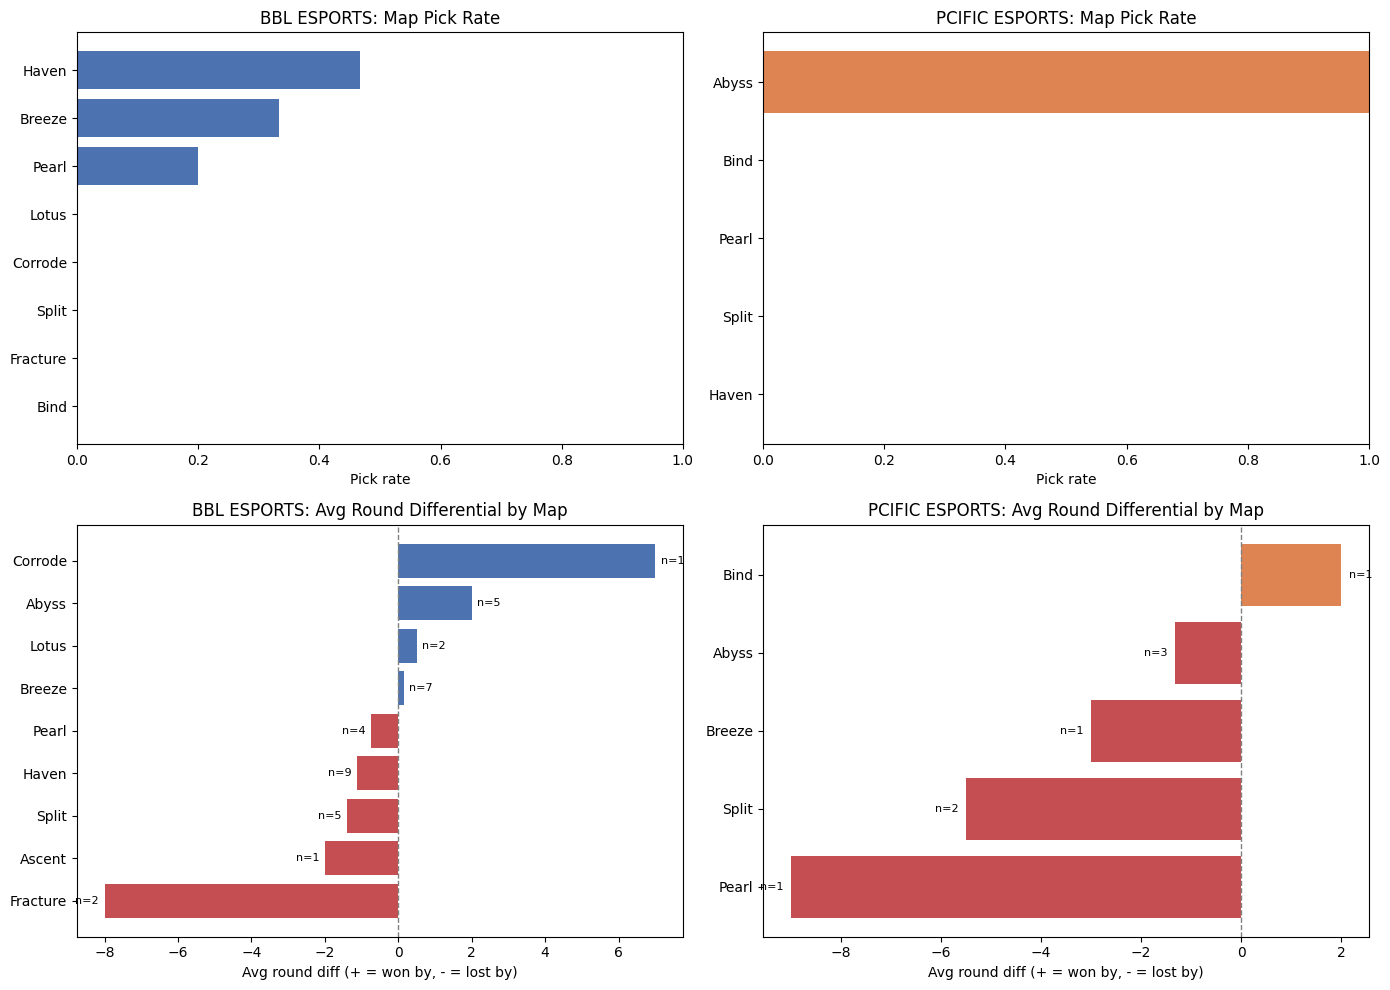

In [14]:
results = analyze_matchup(df, Team1, Team2)

## 10. Patch-aware veto simulation

Uses the map pool actually active on `CURRENT_PATCH`, and the format set in `MATCH_FORMAT` (Cell 6).

In [15]:
CURRENT_PATCH = "12.05-12.08"   # set to whichever patch this match is played on

map_pool = get_map_pool_for_patch(df, CURRENT_PATCH)
print(f"Map pool for patch {CURRENT_PATCH} ({len(map_pool)} maps): {sorted(map_pool)}")

veto_a = veto_tendencies(df, Team1)
veto_b = veto_tendencies(df, Team2)

veto_sequence = simulate_veto(veto_a, veto_b, Team1, Team2, map_pool, match_format=MATCH_FORMAT)
print(f"\nSimulated veto ({MATCH_FORMAT.upper()}): {Team1} vs {Team2}")
for step in veto_sequence:
    print(f"  {step['step']:<20} -> {step['map']}")

Map pool for patch 12.05-12.08 (8 maps): ['Ascent', 'Bind', 'Breeze', 'Fracture', 'Haven', 'Lotus', 'Pearl', 'Split']

Simulated veto (BO3): BBL ESPORTS vs PCIFIC ESPORTS
  BBL ESPORTS bans     -> Bind
  PCIFIC ESPORTS bans  -> Haven
  BBL ESPORTS picks    -> Breeze
  PCIFIC ESPORTS picks -> Ascent
  BBL ESPORTS bans     -> Split
  PCIFIC ESPORTS bans  -> Pearl
  ⚠ UNRESOLVED         -> 2 maps left over: ['Fracture', 'Lotus'] (pool has 8 maps -- BO3 expects 7)
